<a href="https://colab.research.google.com/github/asegura4488/FisicaA/blob/main/Semana7/Campos2D.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

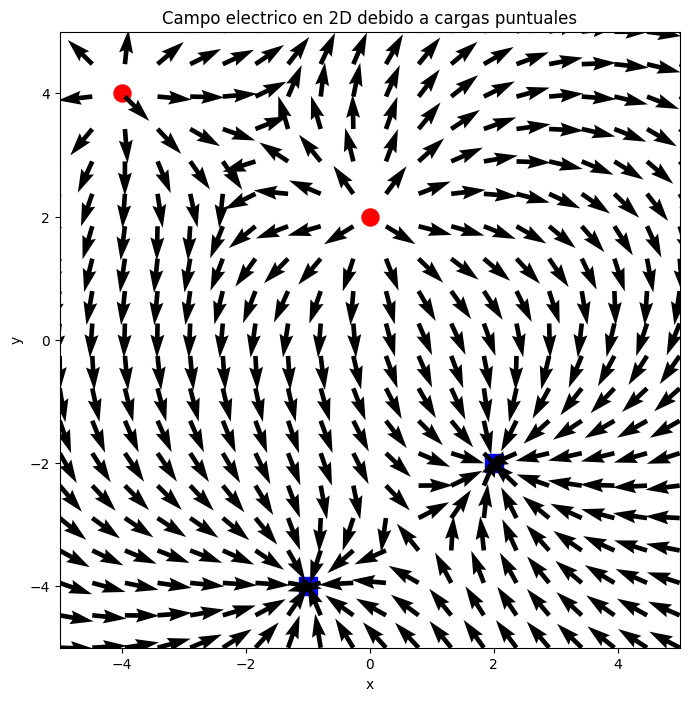

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

# =====================================================
# CAMPO ELECTRICO EN 2D DEBIDO A CARGAS PUNTUALES
# =====================================================

# -----------------------------
# Parametros de la malla
# -----------------------------
N = 20
x = np.linspace(-5, 5, N)
y = np.linspace(-5, 5, N)

X, Y = np.meshgrid(x, y)

# -----------------------------
# Configuracion de cargas
# Cada carga se define como:
# [x0, y0, q]
# -----------------------------
cargas = np.array([
    [0.0,  2.0,  1.0],
    [-1.0, -4.0, -1.0],
    [-4.0,  4.0,  1.0],
    [2.0, -2.0, -1.0]
])

# -----------------------------
# Campo electrico total
# -----------------------------
Ex = np.zeros((N, N))
Ey = np.zeros((N, N))

# -----------------------------
# Funcion de campo puntual en 2D
# -----------------------------
def campo_puntual_2d(x, y, x0, y0, q):
    dx = x - x0
    dy = y - y0

    r2 = dx**2 + dy**2
    r = np.sqrt(r2)

    if r < 1e-6:
        return 0.0, 0.0

    factor = q / r**3
    Ex = factor * dx
    Ey = factor * dy

    return Ex, Ey

# -----------------------------
# Calculo del campo total
# -----------------------------
for k in range(cargas.shape[0]):
    x0, y0, q = cargas[k]

    for i in range(N):
        for j in range(N):
            ex, ey = campo_puntual_2d(x[i], y[j], x0, y0, q)
            Ex[j, i] += ex
            Ey[j, i] += ey

# -----------------------------
# Grafica
# -----------------------------
plt.figure(figsize=(8, 8))

# Dibujar las cargas
for k in range(cargas.shape[0]):
    x0, y0, q = cargas[k]

    if q > 0:
        plt.scatter(x0, y0, s=150, color='red')
    else:
        plt.scatter(x0, y0, s=150, color='blue', marker='s')

# Dibujar los vectores del campo
for i in range(N):
    for j in range(N):
        plt.quiver(x[i], y[j], Ex[j, i], Ey[j, i], color='black')

plt.xlabel("x")
plt.ylabel("y")
plt.title("Campo electrico en 2D debido a cargas puntuales")

plt.xlim(-5, 5)
plt.ylim(-5, 5)

plt.savefig("Campo2D.pdf", dpi=300, bbox_inches="tight")
plt.show()

files.download("Campo2D.pdf")